In [10]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns

In [3]:
# Load the dataset
card_df = pd.read_csv('creditcard.csv')
card_df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
card_df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [7]:
card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
# Check the number of missing values (each column)
card_df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

<Axes: >

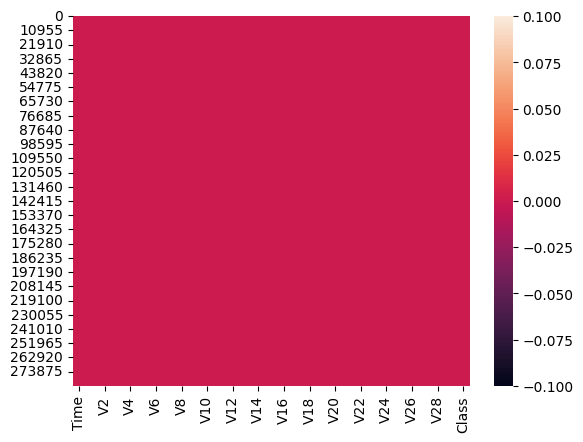

In [12]:
# or check Null values by heatmap
sns.heatmap(card_df.isnull()) 

In [15]:
# distribution of legit transactiona and fraudulent transaction
card_df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#### This Dataset is highly unbalanced

In [35]:
# Seperate data for analysis
legit = card_df[card_df.Class == 0]
fraud = card_df[card_df.Class == 1]
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [37]:
# Statistical measures of the data
legit.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [38]:
 fraud.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [40]:
# compare the values for both transactions (mean of all the columns)
card_df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [45]:
legit_sample = legit.sample(n = 492)
legit_sample

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
276721,167264.0,2.252983,-1.570023,-0.603365,-1.757768,-1.268891,0.290785,-1.662570,0.101446,-1.128053,...,0.126574,0.893242,0.105298,0.309558,-0.138736,0.011883,0.038165,-0.047579,18.85,0
270517,164117.0,-1.469308,2.768754,-0.399928,4.216702,-0.091350,0.736989,-0.404252,1.487058,-2.468109,...,-0.082560,-0.356384,0.295292,0.715586,-0.766490,-0.003995,0.309772,0.198261,6.98,0
192050,129515.0,-8.917048,-9.235122,0.147718,2.204198,3.879406,-3.031205,-1.452848,-1.455326,0.190711,...,-1.245963,-0.746220,3.361500,0.016590,0.662772,-0.748002,0.690373,1.981840,254.50,0
104914,69286.0,1.176095,0.071859,-0.736850,1.582039,2.151296,4.120785,-0.615743,0.986470,-0.325395,...,-0.122112,-0.355119,-0.131217,1.017074,0.776772,0.091031,0.007171,0.016774,23.24,0
260464,159570.0,-0.562756,1.280674,-0.965183,-0.314217,-0.009582,-0.869839,1.887955,-0.665760,0.738944,...,0.070889,0.944085,-0.195402,-0.180015,-0.247972,-0.163312,0.307364,0.048388,169.80,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35790,38267.0,-0.809790,0.574064,2.901121,-0.008900,-0.326948,0.583177,0.176068,0.252692,0.119927,...,-0.037806,0.313885,-0.232995,0.260802,0.085408,0.337771,0.147347,-0.096802,15.00,0
93547,64481.0,-1.001694,1.167127,1.332375,0.234168,0.508602,0.004656,0.653539,-0.053488,-0.228851,...,-0.087149,-0.465164,-0.104910,-0.540202,-0.225812,-0.665032,-0.425645,0.172763,9.99,0
86367,61199.0,-2.147738,0.033420,-0.348492,-0.020371,-0.597771,-0.722867,0.547190,0.817197,-0.064283,...,0.104704,0.251825,0.564363,0.079721,-0.365121,0.337183,0.205626,-0.297169,124.99,0
220947,142366.0,1.989809,-0.961124,-0.352931,-0.665928,-1.262866,-0.417016,-1.304593,0.092814,-0.015413,...,0.254740,0.734715,0.218374,-0.057257,-0.498629,-0.282199,0.049668,-0.009389,49.40,0


In [48]:
new_dataset = pd.concat([legit_sample, fraud], axis = 0)

In [49]:
new_dataset['Class'].value_counts()

Class
0    492
1    492
Name: count, dtype: int64

In [52]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,95323.587398,-0.213013,0.006246,0.022933,-0.019892,0.003678,0.006492,-0.038286,-0.016844,-0.049831,...,-0.009905,0.032839,0.056054,-0.020429,0.008731,-0.005062,-0.058892,-0.000071,0.004669,92.300833
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [56]:
# Splitting the data into features and targets
X = new_dataset.drop(columns = 'Class', axis = 1)
y = new_dataset['Class']

In [58]:
# Split the dataset into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
# need to use 'stratify', to avoid imbalanced seperation of dataset for training and testing 

In [61]:
# Create Logistic Regression 
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

C:\Users\seraf\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [70]:
# Evaluation of the model
from sklearn.metrics import accuracy_score
X_train_pred = model.predict(X_train)
accuracy_score_train = accuracy_score(X_train_pred, y_train)
print(f"Accuracy of training data: {accuracy_score_train: .2f}" )

Accuracy of training data:  0.94


In [71]:
X_test_pred = model.predict(X_test)
accuracy_score_test = accuracy_score(X_test_pred, y_test)
print(f"Accuracy of test data: {accuracy_score_test: .2f}")

Accuracy of test data:  0.94


In [74]:
from sklearn.metrics import classification_report
print(classification_report(X_train_pred, y_train))
print(classification_report(X_test_pred, y_test))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       413
           1       0.91      0.96      0.93       374

    accuracy                           0.94       787
   macro avg       0.94      0.94      0.94       787
weighted avg       0.94      0.94      0.94       787

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        95
           1       0.96      0.92      0.94       102

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197

